# Mother Wavelets

This notebook plots several common mother wavelets in a single figure, with one wavelet per subplot.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def haar(t: np.ndarray) -> np.ndarray:
    return np.where(
        (-0.5 <= t) & (t < 0.0),
        1.0,
        np.where((0.0 <= t) & (t < 0.5), -1.0, 0.0),
    )


def mexican_hat(t: np.ndarray) -> np.ndarray:
    return (1.0 - t**2) * np.exp(-(t**2) / 2.0)


def morlet(t: np.ndarray, omega: float = 5.0) -> np.ndarray:
    correction = np.exp(-(omega**2) / 2.0)
    return (np.cos(omega * t) - correction) * np.exp(-(t**2) / 2.0)


def shannon(t: np.ndarray) -> np.ndarray:
    return np.sinc(t / 2.0) * np.cos(3.0 * np.pi * t / 2.0)


def gaussian_derivative(t: np.ndarray) -> np.ndarray:
    return -t * np.exp(-(t**2) / 2.0)


def difference_of_gaussians(t: np.ndarray) -> np.ndarray:
    narrow = np.exp(-(t**2) / (2.0 * 0.7**2)) / 0.7
    wide = np.exp(-(t**2) / (2.0 * 1.4**2)) / 1.4
    return narrow - wide


def paul(t: np.ndarray, order: int = 4) -> np.ndarray:
    return np.real((1.0 - 1j * t) ** (-(order + 1)))


def gabor(t: np.ndarray, omega: float = 6.0, sigma: float = 1.0) -> np.ndarray:
    return np.sin(omega * t) * np.exp(-(t**2) / (2.0 * sigma**2))


def normalize(y: np.ndarray) -> np.ndarray:
    max_abs = np.max(np.abs(y))
    return y / max_abs if max_abs > 0 else y

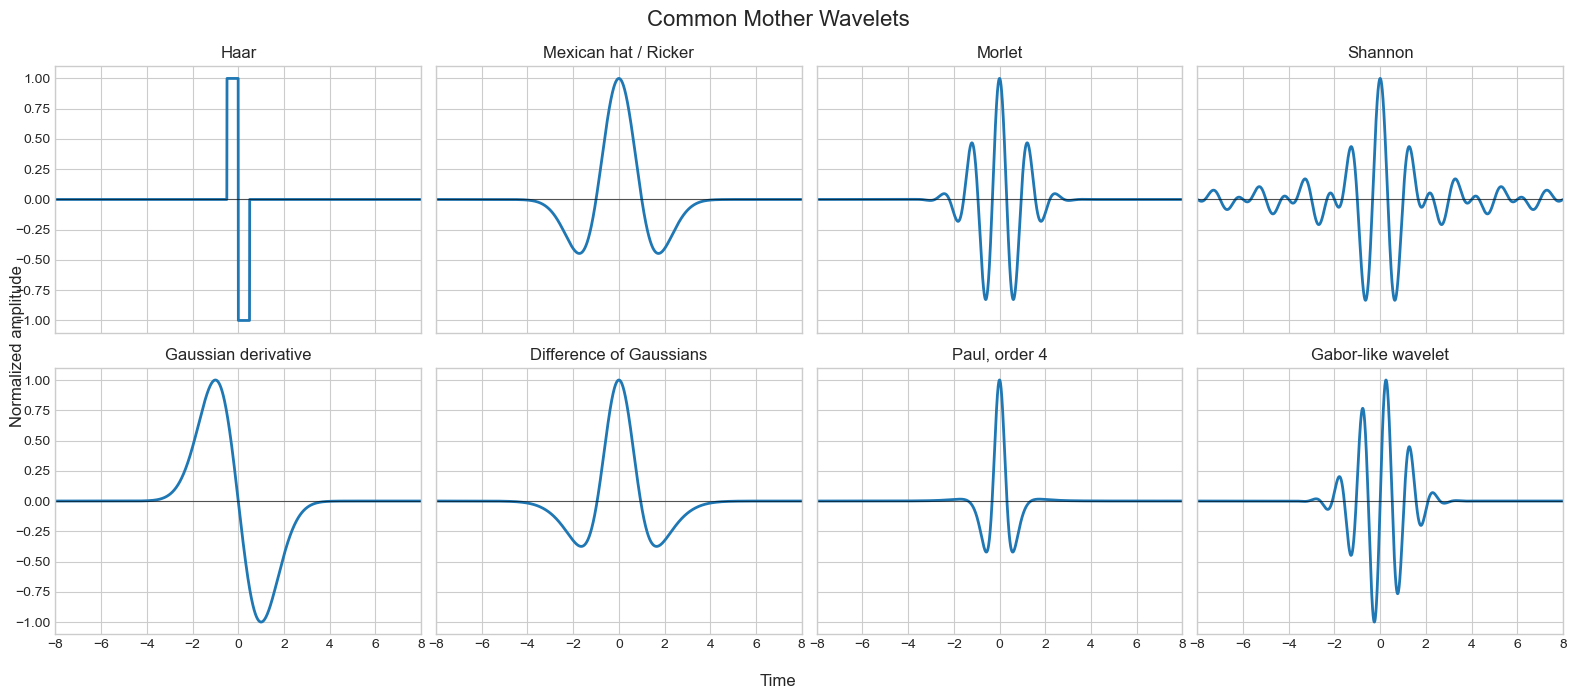

In [3]:
t = np.linspace(-8.0, 8.0, 2_000)

wavelets = {
    "Haar": haar,
    "Mexican hat / Ricker": mexican_hat,
    "Morlet": morlet,
    "Shannon": shannon,
    "Gaussian derivative": gaussian_derivative,
    "Difference of Gaussians": difference_of_gaussians,
    "Paul, order 4": paul,
    "Gabor-like wavelet": gabor,
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, wavelet) in zip(axes, wavelets.items()):
    psi = normalize(wavelet(t))
    ax.plot(t, psi, color="tab:blue", linewidth=2)
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_title(name)
    ax.set_xlim(-8.0, 8.0)
    ax.set_ylim(-1.1, 1.1)

fig.suptitle("Common Mother Wavelets", fontsize=16)
fig.supxlabel("Time")
fig.supylabel("Normalized amplitude")
fig.tight_layout()
plt.show()